In [1]:
import numpy as np
import xarray as xr
from filters import bessel_high_filter
import os
import matplotlib.pyplot as plt
from matplotlib import cm

In [2]:
import tensorrt
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras import layers
from keras.callbacks import History


from tensorflow.keras.optimizers import Adam
from plain_neural_network import*

from keras import backend as K
from filters import bessel_high_filter
import matplotlib.tri as mtri

2024-06-17 22:41:18.313582: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())
import tensorflow as tf; print(tf.config.list_physical_devices('GPU'))

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 13054077675908430179
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 45610434560
locality {
  bus_id: 2
  numa_node: 1
  links {
  }
}
incarnation: 4230599358135005993
physical_device_desc: "device: 0, name: NVIDIA A40, pci bus id: 0000:41:00.0, compute capability: 8.6"
xla_global_id: 416903419
]
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2024-06-17 22:41:21.938654: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /device:GPU:0 with 43497 MB memory:  -> device: 0, name: NVIDIA A40, pci bus id: 0000:41:00.0, compute capability: 8.6


In [4]:
import glob
import random
input_dir = "/albedo/work/user/ssunar/for_paper/new_region_SA/interpolated_data/"
input_file_paths = sorted(glob.glob(input_dir+'*.nc'))

print(len(input_file_paths))
random_num = random.randint(0,len(input_file_paths))

data = xr.open_mfdataset(input_file_paths[:],combine = 'nested', concat_dim="time").astype('float32')
print(data)
X = data.sla.to_numpy()
X = X.transpose(0,2,1)
# y = data.seg_mask.to_numpy()
#X = X.reshape((X.shape[1], X.shape[2], X.shape[3]))
print(X.shape)
# print(y.shape)

1
<xarray.Dataset>
Dimensions:    (time: 31, longitude: 840, latitude: 480)
Coordinates:
  * longitude  (longitude) float32 -70.0 -69.92 -69.83 ... -0.1667 -0.08333
  * latitude   (latitude) float32 -60.0 -59.92 -59.83 ... -20.25 -20.17 -20.08
  * time       (time) float32 5.288e+05 5.289e+05 ... 5.295e+05 5.296e+05
Data variables:
    sla        (time, longitude, latitude) float32 dask.array<chunksize=(31, 840, 480), meta=np.ndarray>
(31, 480, 840)


In [5]:
input_dir = "/albedo/work/user/ssunar/for_paper/new_region_SA/seg_mask/"
input_file_paths = sorted(glob.glob(input_dir+'*.nc'))

print(len(input_file_paths))
random_num = random.randint(0,len(input_file_paths))

data = xr.open_mfdataset(input_file_paths[:],combine = 'nested', concat_dim="time").astype('float32')
print(data)
y = data.seg_mask.to_numpy()
y = y.transpose(0,2,1)
print(y.shape)

1
<xarray.Dataset>
Dimensions:    (time: 31, longitude: 840, latitude: 480)
Coordinates:
  * longitude  (longitude) float32 -70.0 -69.92 -69.83 ... -0.1667 -0.08333
  * latitude   (latitude) float32 -60.0 -59.92 -59.83 ... -20.25 -20.17 -20.08
  * time       (time) float32 5.288e+05 5.289e+05 ... 5.295e+05 5.296e+05
Data variables:
    seg_mask   (time, longitude, latitude) float32 dask.array<chunksize=(31, 840, 480), meta=np.ndarray>
(31, 480, 840)


In [6]:
# from pandas import Timestamp, to_datetime
# from netCDF4 import Dataset, date2num

# outfile = ("/albedo/work/user/ssunar/for_paper/new_region_SA/interpolated_data/SA_new_region_interpol.nc")
# if os.path.isfile(outfile):
#     os.remove(outfile)

# times = data.coords['time'][:].values
# time_unit_out= "hours since 1950-01-01 00:00:00" #hours in case higher resolution output

# fw = Dataset(outfile, 'w')

# #Dimensions
# fw.createDimension('time', 31)
# fw.createDimension('longitude', lon.size)
# fw.createDimension('latitude', lat.size)

# #Variables
# lon3 = fw.createVariable('longitude', 'f', ('longitude',))
# lat3  = fw.createVariable('latitude', 'f', ('latitude',))        
# time = fw.createVariable('time', 'f', ('time',))                  
# sla = fw.createVariable('sla',np.float64, ('time','longitude', 'latitude'))


# #Setting units and descriptions
# lat3.units = 'degrees_north'
# lat3.long_name = 'latitude'
# lon3.units = 'degrees_east'
# lon3.long_name = 'longitude'
# sla.units = 'm'

# time.setncattr('unit',time_unit_out)

# sla.description = 'sea surface elevation bessel filtered with 500km'
# sla.long_name = 'sea surface elevation bessel filtered'

# #Storing co-ordinates
# lon3[:] = lon[:]
# lat3[:] = lat[:]

# lat_ma = np.ma.array(lat[:])
# lon_ma = np.ma.array(lon[:])

# for t in range(X.shape[0]):
#     sla[t] = bessel_high_filter(new_data[t, :, :], wave_length = 500, y_c = lon_ma, x_c = lat_ma).T
#     plt.figure(figsize=(10,10))
#     plt.imshow(np.flipud(sla[t].T), cmap=cm.seismic, vmin=-1, vmax=1)
#     plt.colorbar(orientation='horizontal', pad=0.04)
#     ts=Timestamp(times[t])
#     t1=ts.to_pydatetime()
#     time[t] = date2num(t1, time_unit_out)
# fw.close()

In [7]:
lat.size

NameError: name 'lat' is not defined

In [9]:
lon = np.arange(-70, 0, 1/12)
lat = np.arange(-60, -20, 1/12)

In [11]:
# triang = mtri.Triangulation(lon, lat, elements)

In [8]:
# from scipy.interpolate import interp2d

# lon = np.arange(-70, 0, 1/12)
# lat = np.arange(-60, -20, 1/12)
# X = np.array(X)
# X = np.nan_to_num(X, nan=0.0)
# lon2, lat2 = np.meshgrid(lon, lat)
# new_data = np.ma.empty((X.shape[0], len(lat), len(lon)))
# new_data_with_filter = np.empty((X.shape[0], len(lat), len(lon)))
# # print(len(lat), len(lon))

# for t in range(X.shape[0]):
#     interpolator = interp2d(np.array(data.longitude), np.array(data.latitude), X[t, :, :], kind='linear', bounds_error=False, fill_value=None)
#     interpolated_values = interpolator(lon, lat) 
#     new_data[t, :, :] = np.ma.masked_equal(interpolated_values, 0)
# #     new_data[t, :, :].mask = np.zeros(new_data[t, :, :].shape, dtype=bool)
    
# # Basel filter from line below.

In [12]:
# lat_ma = np.ma.array(lat[:])
# lon_ma = np.ma.array(lon[:])

# for t in range(X.shape[0]):
#     new_data_with_filter[t, :, :] = bessel_high_filter(new_data[t, :, :], wave_length = 500, y_c = lon, x_c = lat)


# # Check this

/tmp/ipykernel_1409860/1416017759.py:5: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  axs[0].pcolormesh(lon, lat, new_data[0,:,:], cmap=cm.seismic, vmin=-1, vmax=1)
/tmp/ipykernel_1409860/1416017759.py:9: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  axs[1].pcolormesh(lon, lat, new_data_with_filter[0,:,:], cmap=cm.seismic, vmin=-1, vmax=1)


Text(0.5, 1.0, 'Prediction - model trained on South Atlantic region')

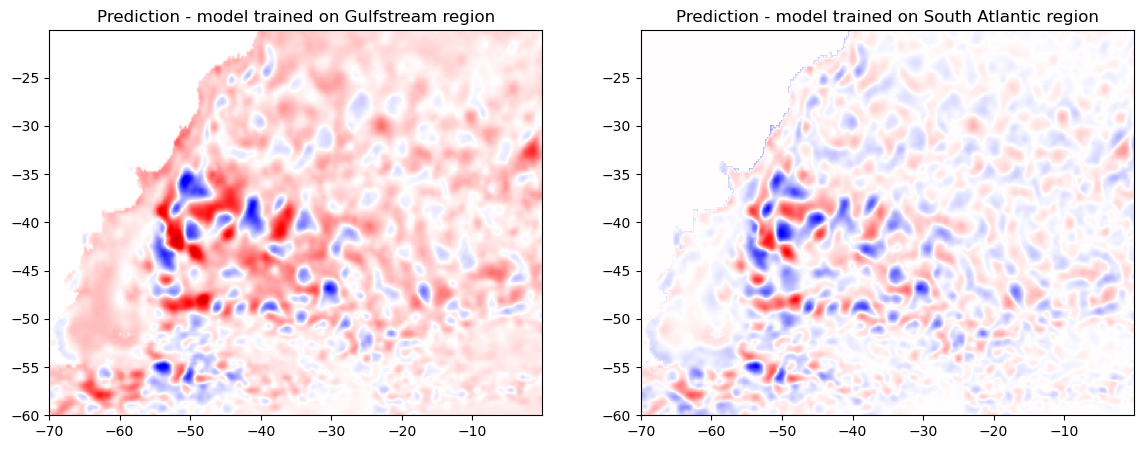

In [14]:
# Prediction of South Atlantic data using Model trained in Gulfstream region
dir_path = "/albedo/work/user/ssunar/for_paper/new_region_SA/"
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].pcolormesh(lon, lat, new_data[0,:,:], cmap=cm.seismic, vmin=-1, vmax=1)

axs[0].set_title('Prediction - model trained on Gulfstream region')

axs[1].pcolormesh(lon, lat, new_data_with_filter[0,:,:], cmap=cm.seismic, vmin=-1, vmax=1)
axs[1].set_title('Prediction - model trained on South Atlantic region')

In [10]:
# data_long = data.longitude
# data_lat = data.latitude
# xx, yy = np.meshgrid(data_long, data_lat)
lon2, lat2 = np.meshgrid(lon, lat)
xx, yy = lon2, lat2

In [11]:
X.setflags(write=1)
X.flags

  C_CONTIGUOUS : False
  F_CONTIGUOUS : False
  OWNDATA : False
  WRITEABLE : True
  ALIGNED : True
  WRITEBACKIFCOPY : False

In [12]:
# img_size = (160, 280)
img_size = (480, 840)
num_classes = 3
weight_path_gulfstream = "/albedo/work/user/ssunar/for_paper/unet_trained/Gulfstream/train/weights.h5"
preds_y_gf = using_model_(img_size, num_classes, X, weight_path_gulfstream)
print(preds_y_gf.shape)

2024-06-17 22:42:44.465794: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 43497 MB memory:  -> device: 0, name: NVIDIA A40, pci bus id: 0000:41:00.0, compute capability: 8.6
2024-06-17 22:42:47.278359: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8904


1/1 [==============================] - 5s 5s/step
(31, 480, 840)


2024-06-17 22:42:50.271038: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


In [13]:
weight_path_sa = "/albedo/work/user/ssunar/for_paper/unet_trained/south_atlantic/train/weights.h5"
preds_y_sa = using_model_(img_size, num_classes, X, weight_path_sa)
print(preds_y_sa.shape)

1/1 [==============================] - 0s 231ms/step
(31, 480, 840)


(31, 480, 840)

/tmp/ipykernel_985144/649361259.py:5: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  axs[0].pcolormesh(lon, lat, X[1,:,:], cmap=cm.seismic, vmin=-1, vmax=1)
/tmp/ipykernel_985144/649361259.py:9: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  axs[1].pcolormesh(lon, lat, X[1,:,:], cmap=cm.seismic, vmin=-1, vmax=1)


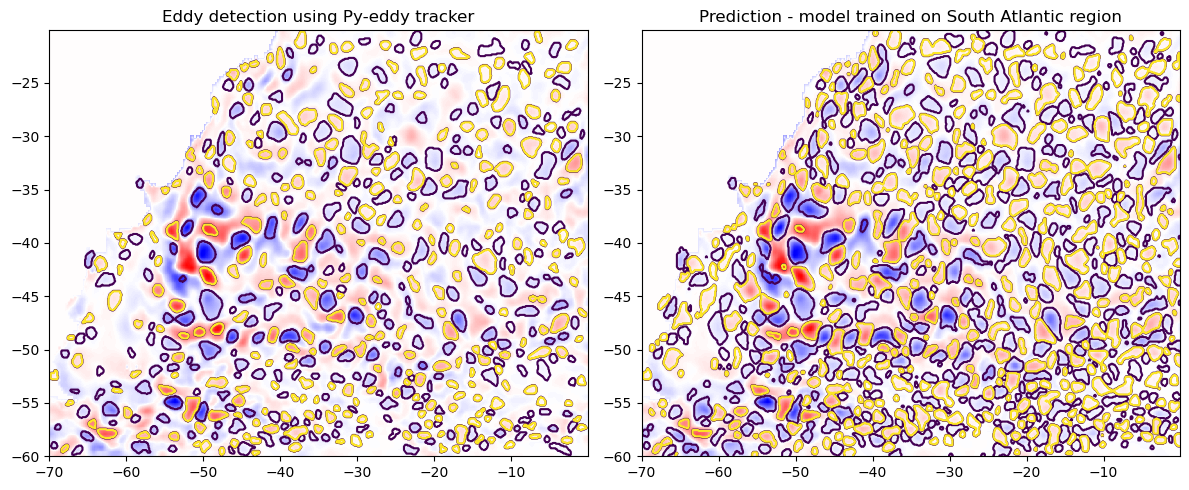

In [16]:
# Prediction of South Atlantic data using Model trained in Gulfstream region
dir_path = "/albedo/work/user/ssunar/for_paper/new_region_SA/"
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].pcolormesh(lon, lat, X[1,:,:], cmap=cm.seismic, vmin=-1, vmax=1)
axs[0].contour(xx, yy, y[1,:,:], levels=[0,1])
axs[0].set_title('Eddy detection using Py-eddy tracker')

axs[1].pcolormesh(lon, lat, X[1,:,:], cmap=cm.seismic, vmin=-1, vmax=1)
axs[1].contour(xx, yy, preds_y_sa[1,:,:], levels=[0,1])
axs[1].set_title('Prediction on South Atlantic region')

plt.tight_layout()
plt.savefig(dir_path + "SA_sla_prediction.png", dpi = 300)
plt.show()